___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Copyright by Pierian Data Inc.</em></center>
<center><em>For more information, visit us at <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Keras RL DQN on Image Environment - Exercise - 




In thise notebook you will implement a DQN agent on the famous game of Pong:
**Use the Pong-v0 environment**
(https://gymnasium.farama.org/v0.28.1/environments/atari/pong/ <br />

**TASK: Import necessary libraries and create the environment. Also extract the possible actions** <br />

In [1]:
#TODO
import warnings
warnings.filterwarnings("ignore")

In [1]:
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt
%config InlineBackened.format_figure = "retina"

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Flatten , Activation , Convolution2D , Permute
from tensorflow.keras.optimizers import Adam

In [3]:
import gymnasium as gym
from gymnasium.utils.play import play

C:\Users\ahmad\anaconda3\envs\rl_env\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [4]:
from rl.callbacks import FileLogger , ModelIntervalCheckpoint

In [5]:
import ale_py

In [6]:
gym.register_envs(ale_py)

In [7]:
env_name = "ALE/Pong-v5"

In [8]:
env = gym.make(env_name , render_mode = "rgb_array")
nb_actions = env.action_space.n
nb_actions

6

In [9]:
class OldAPIWrapper(gym.Env):
    def __init__(self, env):
        self.env = env
        self.observation_space = env.observation_space
        self.action_space = env.action_space

    def reset(self):
        obs, info = self.env.reset()
        return obs  # return only obs, not the tuple

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        return obs, reward, done, info 

    def render(self , mode = "human"):
        return self.env.render()

    def close(self):
        return self.env.close()

**TASK: Play the game manually (keys: a and d to move the bars)** <br />

In [11]:
play(env)

In [14]:
%matplotlib inline

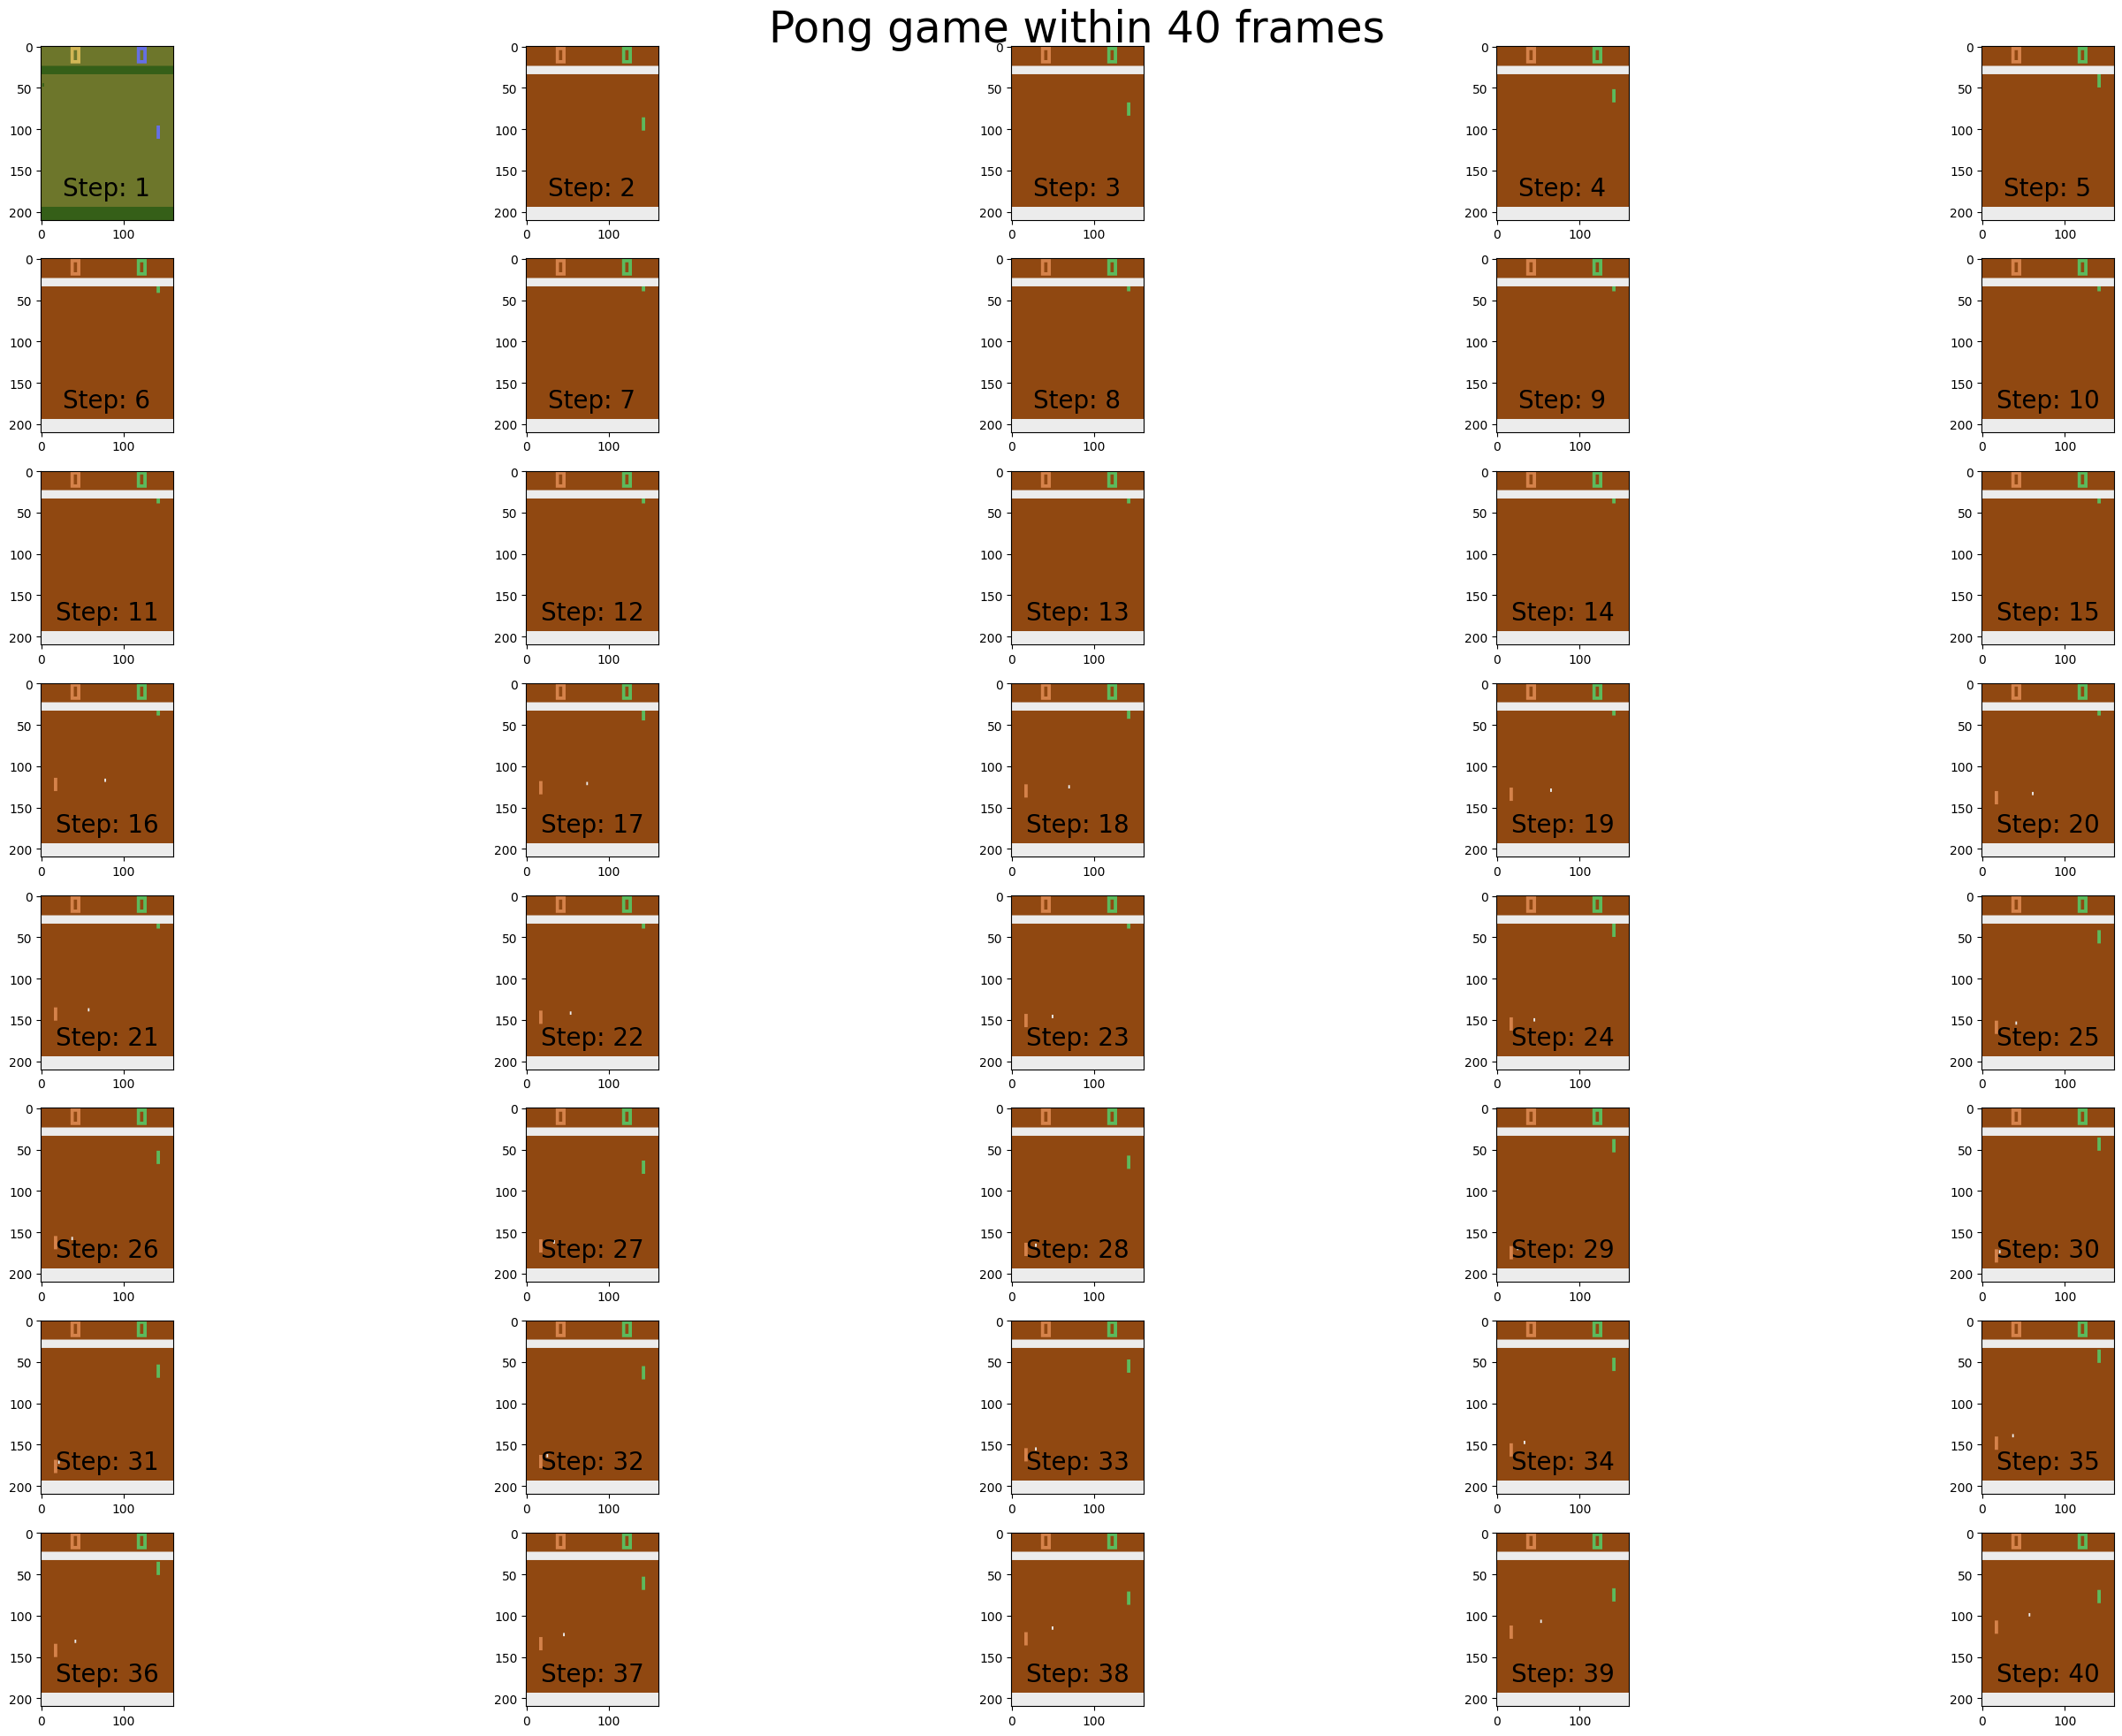

In [17]:
stae , info = env.reset()

fig , ax = plt.subplots(figsize = (30 , 20) , nrows = 8 , ncols = 5 , constrained_layout = True)
ax_flat = ax.flatten()

for i in range(40):
    frame = env.render()
    action = env.action_space.sample()
    state , reward , truncated , terminated , info = env.step(action)


    ax_flat[i].imshow(frame)
    ax_flat[i].set_title(f"Step: {i+1}" , y = 0.1 , fontsize = 20)
    ax_flat[i].axis("on")
        
fig.suptitle(t = "Pong game within 40 frames" , fontsize = 35)
fig.tight_layout()
plt.show()
env.close()

**TASK: Define an input size and the window length** <br />

In [10]:
#TODO
IMG_SHAPE = (84 , 84)
WINDOW_LENGTH = 4

In [11]:
input_shape = (WINDOW_LENGTH , IMG_SHAPE[0] , IMG_SHAPE[1])
input_shape

(4, 84, 84)

**TASK: Create the ImageProcessor** <br />
It needs to:
1. Resize the image
2. Convert it to grayscale
3. Standardize it
4. Be memory efficient

Dont forget the reward clipping

In [12]:
from rl.core import Processor

In [13]:
#TODO
class ImageProcessor(Processor):
    def process_observation(self , observation):
        img = Image.fromarray(observation)
        img = img.resize(IMG_SHAPE)
        img = img.convert("L")
        img = np.array(img)

        return img.astype("uint8")

    def process_state_batch(self , batch):
        processed_batch = batch.astype('float32')/255
        return processed_batch

    def process_reward(self , reward):
        return np.clip(reward , -1 , +1)

**TASK: Design the Convolutional Neural Network** <br />
Hint: Make sure to get the right input shape!

You can try the same architecture than presented in the previous notebook:
1. Conv2D(filters=32, kernel_size=8, stride=4)
2. Conv2D(filters=64, kernel_size=4, stride=2)
3. Conv2D(filters=64, kernel_size=3, stride=1)
4. Dense(512)

Dont forget the activation function

In [25]:
#TODO

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten
from tensorflow.keras.optimizers import Adam
from rl.agents.dqn import DQNAgent
from rl.policy import EpsGreedyQPolicy
from rl.memory import SequentialMemory

model = Sequential()
model.add(Permute(dims = (2 , 3 , 1) , input_shape = input_shape))

model.add(Convolution2D(filters = 32 , kernel_size = 8 , strides = (4 , 4) , kernel_initializer = "he_normal"))
model.add(Activation("relu"))

model.add(Convolution2D(filters = 64 , kernel_size = 4 , strides = (2 , 2) , kernel_initializer = "he_normal"))
model.add(Activation("relu"))

model.add(Convolution2D(filters = 64 , kernel_size = 3 , strides = (1 , 1) , kernel_initializer = "he_normal"))
model.add(Activation("relu"))

model.add(Flatten())

model.add(Dense(units = 512))
model.add(Activation(activation = "relu"))

model.add(Dense(units = nb_actions))
model.add(Activation(activation =  "linear"))

In [26]:
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 permute_1 (Permute)         (None, 84, 84, 4)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 20, 20, 32)        8224      
                                                                 
 activation_5 (Activation)   (None, 20, 20, 32)        0         
                                                                 
 conv2d_4 (Conv2D)           (None, 9, 9, 64)          32832     
                                                                 
 activation_6 (Activation)   (None, 9, 9, 64)          0         
                                                                 
 conv2d_5 (Conv2D)           (None, 7, 7, 64)          36928     
                                                                 
 activation_7 (Activation)   (None, 7, 7, 64)         

**TASK: Create the Replay Memory** <br />


In [27]:
from rl.memory import SequentialMemory

In [28]:
#TODO
memory = SequentialMemory(limit = 1000000 , window_length = WINDOW_LENGTH)

**TASK: Create the processor** <br />


In [29]:
from rl.core import Processor

In [30]:
#TODO
processor = ImageProcessor()

**TASK: Define the action selection policy.** <br />
Feel free to try all policies you like. (Hint: decaying epsilon greedy also works here)

In [31]:
from rl.policy import EpsGreedyQPolicy , LinearAnnealedPolicy

In [32]:
#TODO
policy = LinearAnnealedPolicy(inner_policy = EpsGreedyQPolicy() , 
                              attr = "eps" ,
                              value_max = 1 ,
                              value_min = 0.1 ,
                              value_test = 0.05 ,
                              nb_steps = 1000000)

**TASK: Create the agent.** <br />
Dont forget to compile!

In [33]:
from rl.agents.dqn import DQNAgent

In [34]:
#TODO
dqn = DQNAgent(model=model, 
               nb_actions=nb_actions,
               policy=policy, 
               memory=memory,
               processor=processor, 
               nb_steps_warmup=50000, 
               gamma=.99, 
               target_model_update=10000,
               train_interval=4, 
               delta_clip=1)

In [35]:
dqn.compile(Adam(learning_rate = 0.00025) , metrics = ["mae"])

**TASK: Define a checkpoint callback to store the weights during training.** <br />
Please name it differently than our provided checkpoint to avoid overwriting it

In [36]:
#TODO
weights_filename = 'dqn_breakout_weights.h5f'
checkpoint_weights_filename = 'dqn_' + "BreakoutDeterministic-v4" + '_weights_{step}.h5f'
checkpoint_callback = ModelIntervalCheckpoint(checkpoint_weights_filename, interval=100000)

**TASK: Train the agent.** <br />

In [37]:
env = OldAPIWrapper(gym.make(env_name))

In [38]:
#TODO
dqn.fit(env,
        nb_steps=5000,
        callbacks = [checkpoint_callback],
        log_interval = 500 ,
        visualize = False
       )

Training for 5000 steps ...
Interval 1 (0 steps performed)
  1/500 [..............................] - ETA: 1:09 - reward: 0.0000e+00

C:\Users\ahmad\anaconda3\envs\rl_env\lib\site-packages\keras\engine\training_v1.py:2356: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


500/500 [==============================] - 3s 7ms/step - reward: -0.0260
Interval 2 (500 steps performed)
500/500 [==============================] - 3s 6ms/step - reward: -0.0200
1 episodes - episode_reward: -21.000 [-21.000, -21.000] - lives: 0.000 - episode_frame_number: 2181.648 - frame_number: 3002.000

Interval 3 (1000 steps performed)
500/500 [==============================] - 3s 7ms/step - reward: -0.0280
Interval 4 (1500 steps performed)
500/500 [==============================] - 3s 7ms/step - reward: -0.0280
1 episodes - episode_reward: -21.000 [-21.000, -21.000] - lives: 0.000 - episode_frame_number: 1314.576 - frame_number: 7002.000

Interval 5 (2000 steps performed)
500/500 [==============================] - 3s 7ms/step - reward: -0.0220
Interval 6 (2500 steps performed)
500/500 [==============================] - 3s 6ms/step - reward: -0.0180
1 episodes - episode_reward: -21.000 [-21.000, -21.000] - lives: 0.000 - episode_frame_number: 1004.824 - frame_number: 11002.000

In

In [39]:
dqn.save_weights(weights_filename, overwrite=True)

**TASK: Evaluate the agent.** <br />

In [40]:
#TODO
env2 = OldAPIWrapper(gym.make(id = env_name , render_mode = "rgb_array"))
dqn.test(env2, nb_episodes=5, visualize=True)

Testing for 5 episodes ...
Episode 1: reward: -21.000, steps: 764
Episode 2: reward: -21.000, steps: 764
Episode 3: reward: -21.000, steps: 764
Episode 4: reward: -21.000, steps: 764
Episode 5: reward: -21.000, steps: 764


In [ ]:
#TODO
env3 = OldAPIWrapper(gym.make(id = env_name , render_mode = "human"))
dqn.test(env3, nb_episodes=5, visualize=True)

Testing for 5 episodes ...
Episode 1: reward: -21.000, steps: 764
Episode 2: reward: -21.000, steps: 764
Episode 3: reward: -21.000, steps: 764
Episode 4: reward: -21.000, steps: 764


**TASK: Load your weights (or the provided ones) and create an agent from those** <br />

In [41]:
#TODO
model.load_weights("weights_exercise/dqn_PONG_weights_1500000.h5f")


memory = SequentialMemory(limit = 1000000 , window_length = WINDOW_LENGTH)
policy = LinearAnnealedPolicy(inner_policy = EpsGreedyQPolicy() , 
                              attr = "eps" ,
                              value_max = 1 ,
                              value_min = 0.1 ,
                              value_test = 0.05 ,
                              nb_steps = 100000)

processor = ImageProcessor()

dqn = DQNAgent(model=model, 
               nb_actions=nb_actions,
               policy=policy, 
               memory=memory,
               processor=processor, 
               nb_steps_warmup=50000, 
               gamma=.99, 
               target_model_update=10000
              )

dqn.compile(Adam(learning_rate = 0.00025) , metrics = ["mae"])


In [42]:
env3 = OldAPIWrapper(gym.make(id = env_name , render_mode = "human"))
dqn.test(env3, nb_episodes=15, visualize=True)

Testing for 5 episodes ...


C:\Users\ahmad\anaconda3\envs\rl_env\lib\site-packages\keras\engine\training_v1.py:2356: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Episode 1: reward: -18.000, steps: 2489
Episode 2: reward: -14.000, steps: 3574
Episode 3: reward: -14.000, steps: 2672
Episode 4: reward: -17.000, steps: 2957
Episode 5: reward: -11.000, steps: 4244
